<a href="https://colab.research.google.com/github/fahmiiys12/ML/blob/main/FAHMI_ISMA_YUDA_2417051062_A_UTP_RespML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#####NAMA: FAHMI ISMA YUDA SENA <br>
#####NPM: 2417051062<br>
#####KELAS: ILKOM A<br><br><br>

##SHIP PERFORMANCE DATASET - UNSUPERVISED CLUSTERING
##HIRARCHICAL CLUSTERING dan DBSCAN

Tujuan: Melakukan EDA, Preprocessing, dan Clustering pada dataset performa kapal menggunakan algoritma unsupervised learning: **Hierarchical Clustering** dan **DBSCAN**.


###Alasan Pemilihan Algoritma:
1. **Hierarchical Clustering** dipilih karena:
   - Tidak perlu menentukan jumlah cluster di awal (menggunakan dendrogram)
   - Cocok untuk data dengan struktur hierarki/nested
   - Mudah divisualisasikan dengan dendrogram untuk interpretasi cluster
   - Robust terhadap outlier jika menggunakan linkage yang tepat

2. **DBSCAN** dipilih karena:
   - Dapat mendeteksi cluster dengan bentuk sembarang (non-spherical)
   - Secara otomatis mendeteksi outlier/noise points
   - Tidak memerlukan spesifikasi jumlah cluster
   - Sangat cocok untuk data performa kapal yang mungkin memiliki pola distribusi tidak beraturan

#1. UPLOADD LIBRARY DAN LOAD DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print(' Library berhasil diimport!')

 Library berhasil diimport!


In [ ]:
url = 'https://raw.githubusercontent.com/oshlite/DatasetML/main/Ship_Performance_Dataset.csv'
df = pd.read_csv(url)

print(f' Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')

 Dataset berhasil dimuat!
Shape: (2736, 18)
Jumlah baris: 2736, Jumlah kolom: 18


#2. EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
print('='*60)
print('GAMBARAN UMUM DATASET')
print('='*60)
df.head(10)

GAMBARAN UMUM DATASET


,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
5,2023-07-09,Fish Carrier,Long-haul,Heavy Fuel Oil (HFO),Fair,18.616196,2171.646567,723.304215,14.916320,Rough,1912.509751,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898
6,2023-07-16,Fish Carrier,Transoceanic,Heavy Fuel Oil (HFO),Critical,20.433119,2505.043509,270.118588,8.455264,Rough,1191.436412,434449.263514,739431.825390,29.040420,1.120389,0.602932,3,58.508635
7,2023-07-23,Container Ship,Short-haul,Diesel,Critical,23.498048,814.806452,1717.328413,9.283780,Moderate,318.449265,348380.608232,462211.402199,52.478600,0.695975,1.408663,6,94.591972
8,2023-07-30,NaN,Coastal,Heavy Fuel Oil (HFO),Good,17.309362,1179.018805,429.564313,6.002358,Moderate,1953.447929,346071.519942,448682.864128,14.451820,0.977448,0.764914,8,50.247060
9,2023-08-06,Container Ship,Long-haul,Diesel,Fair,23.227101,2685.401654,1588.792282,11.721261,Calm,1843.438252,149790.209291,615230.857491,63.742761,0.440676,1.435569,2,79.451330


In [ ]:
print('\n--- INFO DATASET ---')
df.info()


--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Ef

In [ ]:
print('\n--- STATISTIK DESKRIPTIF ---')
df.describe().T.style.background_gradient(cmap='Blues')


--- STATISTIK DESKRIPTIF ---


,count,mean,std,min,25%,50%,75%,max
Speed_Over_Ground_knots,2736.000000,17.602863,4.311979,10.009756,13.928452,17.713757,21.284785,24.997043
Engine_Power_kW,2736.000000,1757.610939,717.002777,501.025220,1148.104914,1757.494344,2382.594292,2998.734329
Distance_Traveled_nm,2736.000000,1036.406203,568.632080,50.433150,548.511573,1037.816060,1540.934161,1998.337057
Draft_meters,2736.000000,9.929103,2.876423,5.001947,7.437485,9.918965,12.413149,14.992947
Cargo_Weight_tons,2736.000000,1032.573264,558.697499,50.229624,553.983629,1043.207497,1527.722391,1999.126697
Operational_Cost_USD,2736.000000,255143.344488,140890.482189,10092.306318,131293.378767,257157.653226,381796.930499,499734.867868
Revenue_per_Voyage_USD,2736.000000,521362.062011,271211.625499,50351.814447,290346.388017,520176.931762,750072.791216,999916.696140
Turnaround_Time_hours,2736.000000,41.747536,17.633130,12.019909,26.173537,41.585188,57.363922,71.972415
Efficiency_nm_per_kWh,2736.000000,0.798656,0.403590,0.100211,0.463592,0.789877,1.147426,1.499259
Seasonal_Impact_Score,2736.000000,1.003816,0.288251,0.500004,0.758033,1.009009,1.252808,1.499224



--- MISSING VALUES ---
                    Missing Count  Missing (%)
Ship_Type                     136      4.97076
Route_Type                    136      4.97076
Engine_Type                   136      4.97076
Maintenance_Status            136      4.97076
Weather_Condition             136      4.97076


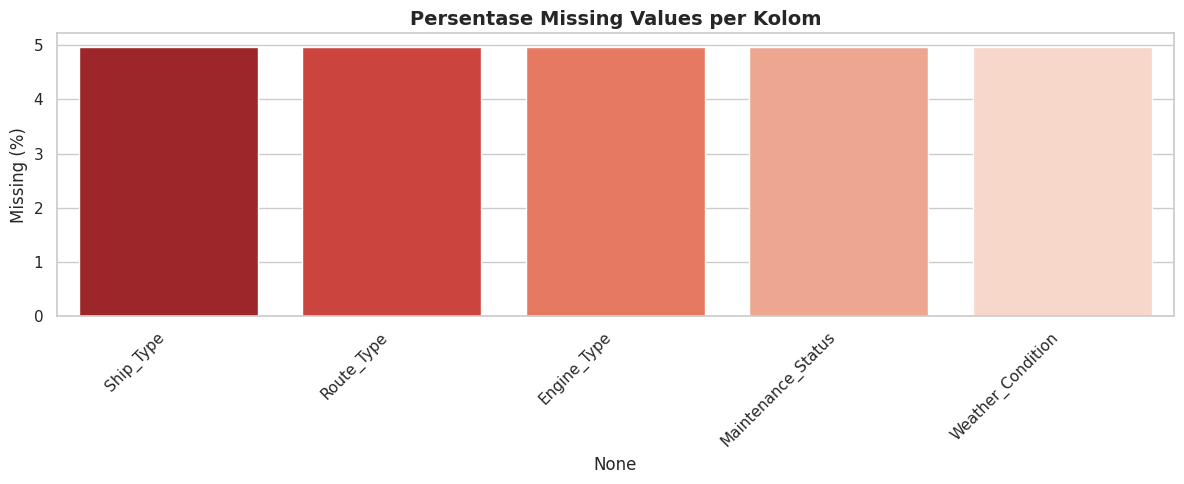

In [ ]:
print('\n--- MISSING VALUES ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

if missing_df.empty:
    print(' Tidak ada missing values!')
else:
    print(missing_df)

    plt.figure(figsize=(12, 5))
    sns.barplot(x=missing_df.index, y='Missing (%)', data=missing_df, palette='Reds_r')
    plt.title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing (%)')
    plt.tight_layout()
    plt.show()

In [ ]:
print('\n--- DUPLIKAT ---')
dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup}')
if dup > 0:
    print(df[df.duplicated()])


--- DUPLIKAT ---
Jumlah baris duplikat: 0


In [ ]:
print('\n--- TIPE DATA ---')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Kolom Kategorik ({len(cat_cols)}): {cat_cols}')
print(f'Kolom Numerik  ({len(num_cols)}): {num_cols}')


--- TIPE DATA ---
Kolom Kategorik (6): ['Date', 'Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
Kolom Numerik  (12): ['Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm', 'Draft_meters', 'Cargo_Weight_tons', 'Operational_Cost_USD', 'Revenue_per_Voyage_USD', 'Turnaround_Time_hours', 'Efficiency_nm_per_kWh', 'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage']


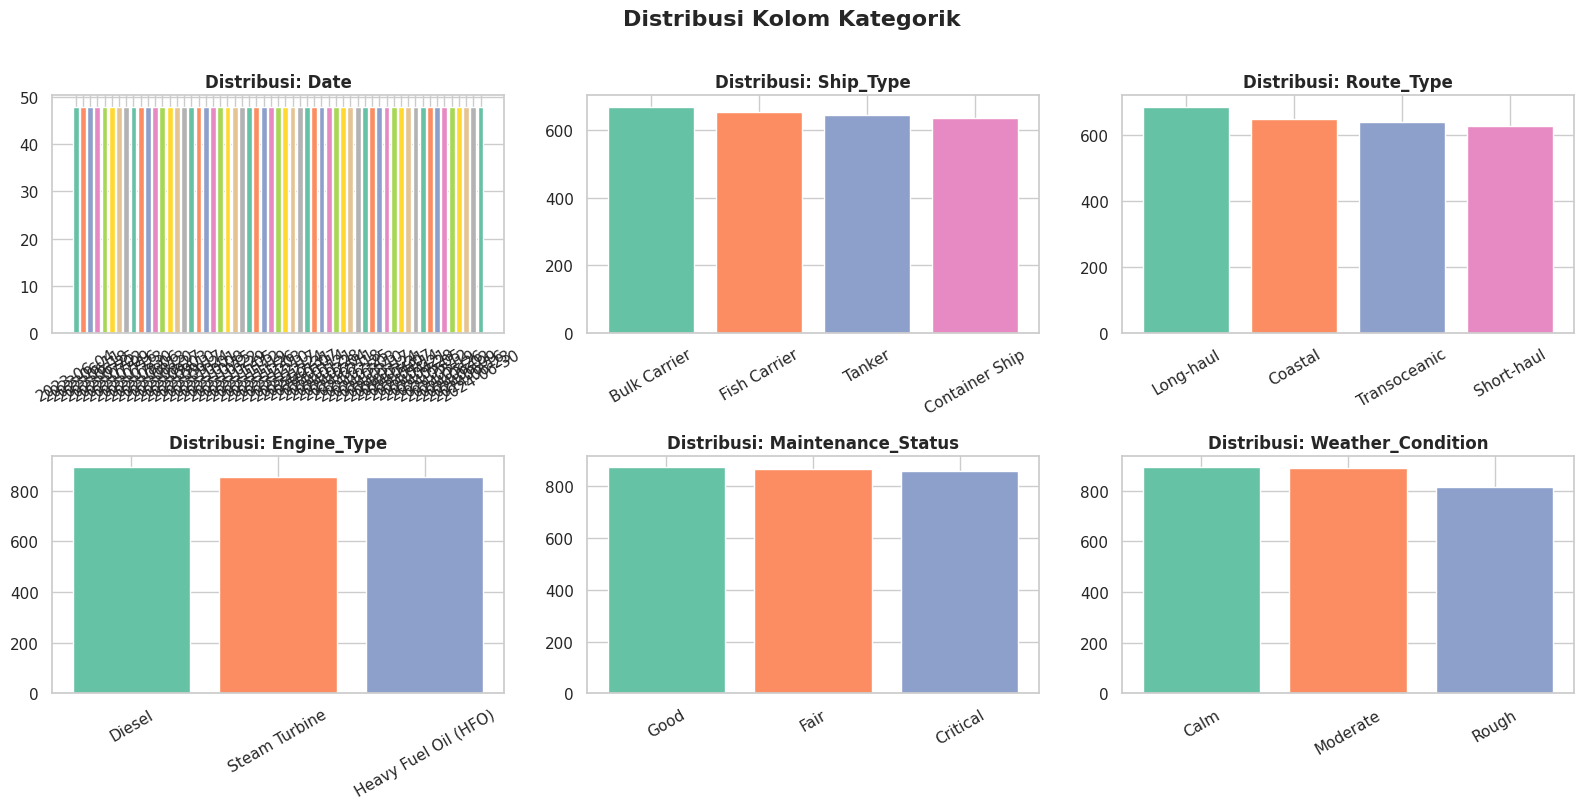

In [ ]:
if cat_cols:
    n = len(cat_cols)
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, min(n, cols_per_row), figsize=(16, 4*rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(cat_cols):
        vc = df[col].value_counts()
        axes[i].bar(vc.index.astype(str), vc.values, color=sns.color_palette('Set2', len(vc)))
        axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=30)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Distribusi Kolom Kategorik', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

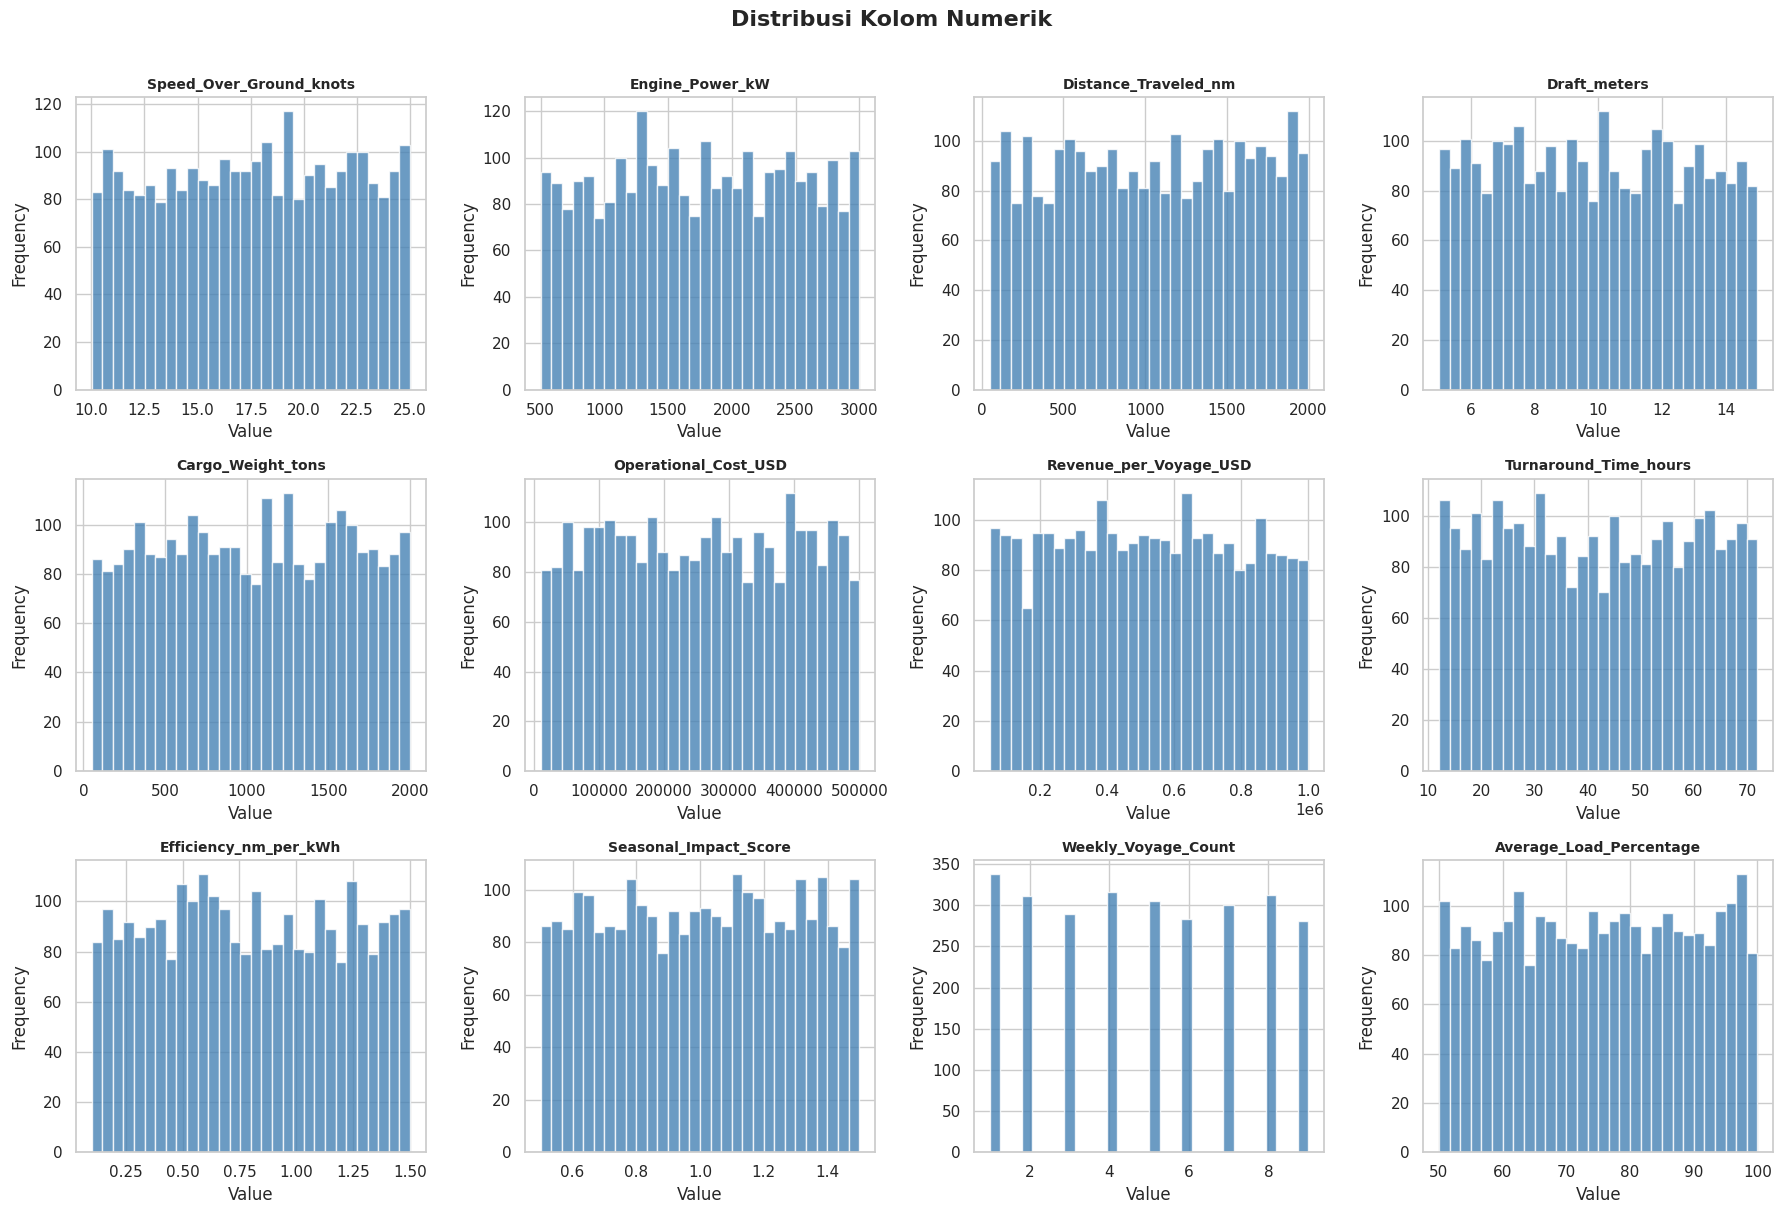

In [ ]:
if num_cols:
    n = len(num_cols)
    cols_per_row = 4
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, min(n, cols_per_row), figsize=(18, 4*rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Distribusi Kolom Numerik', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

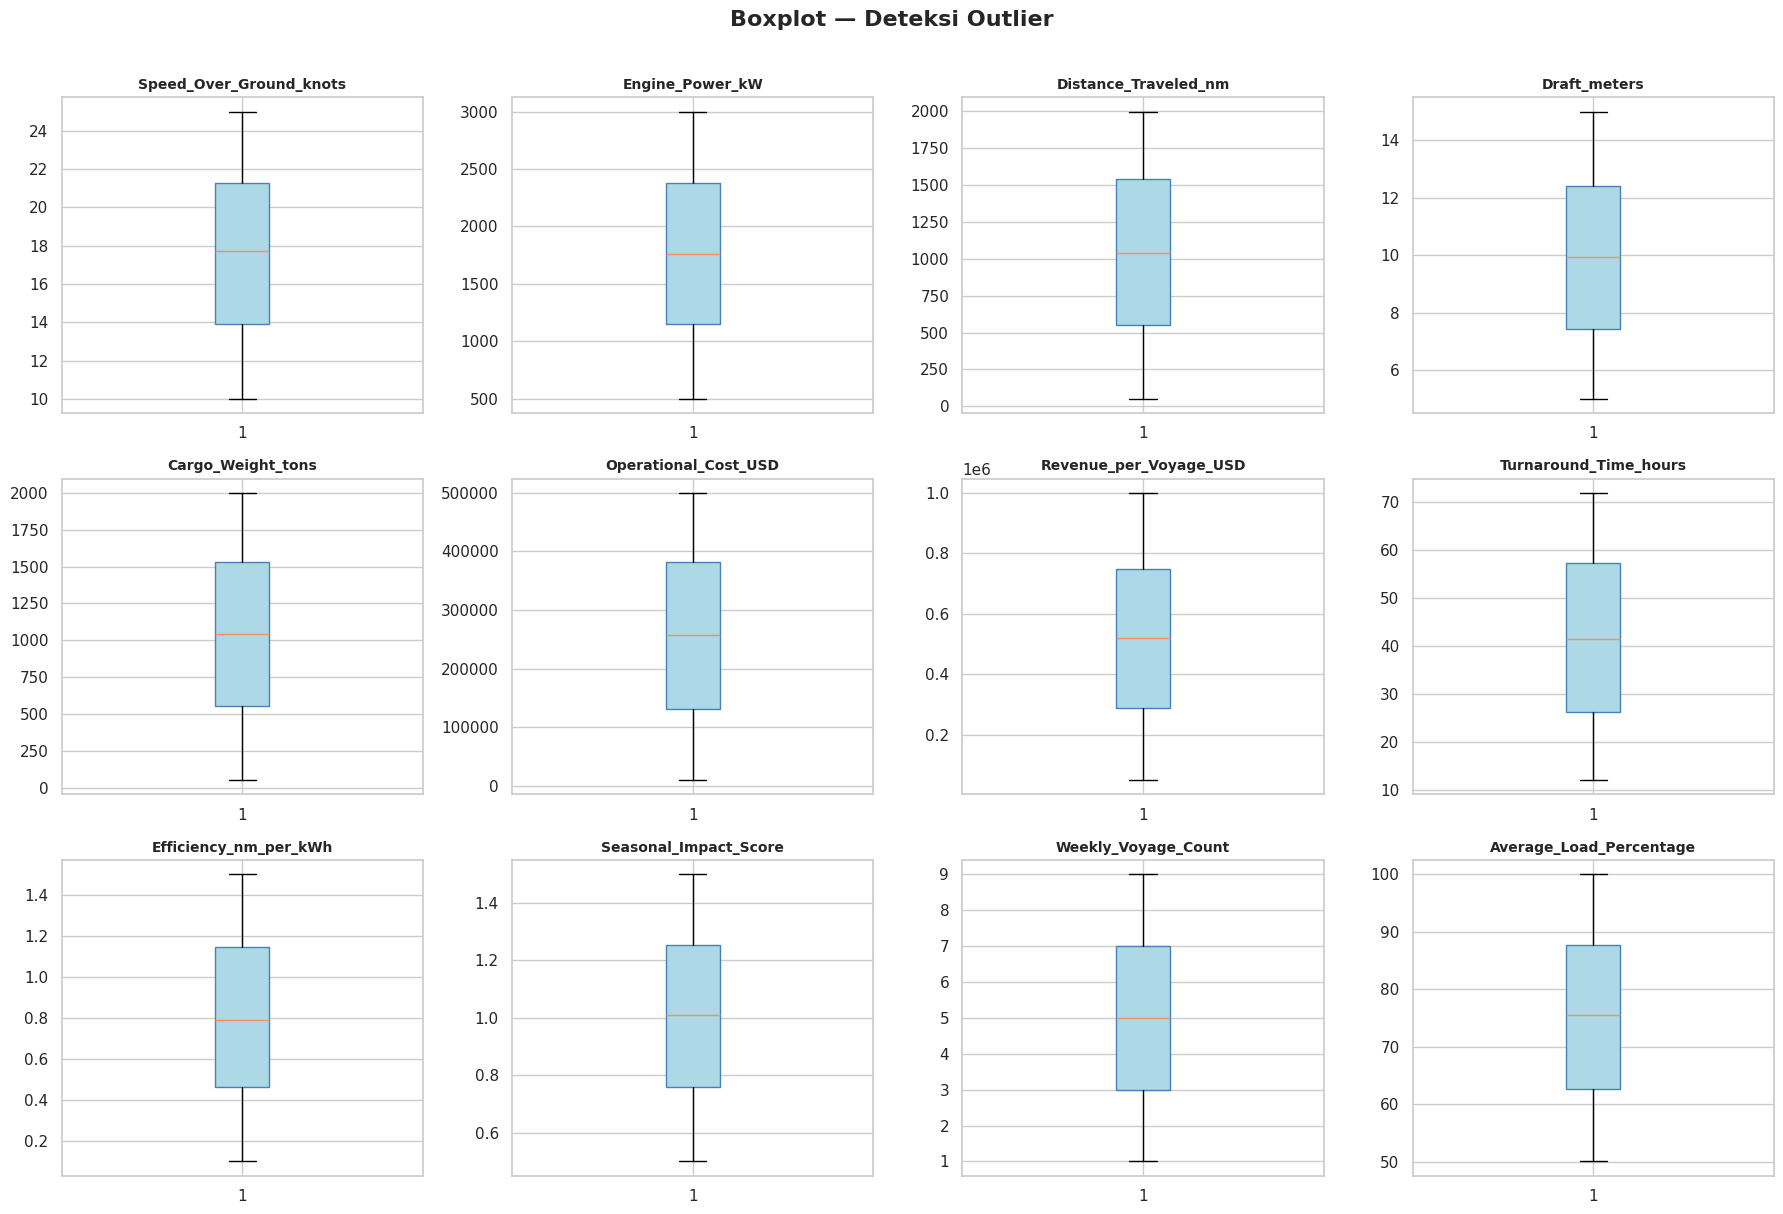

In [ ]:
if num_cols:
    n = len(num_cols)
    cols_per_row = 4
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, min(n, cols_per_row), figsize=(18, 4*rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='steelblue'))
        axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplot — Deteksi Outlier', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

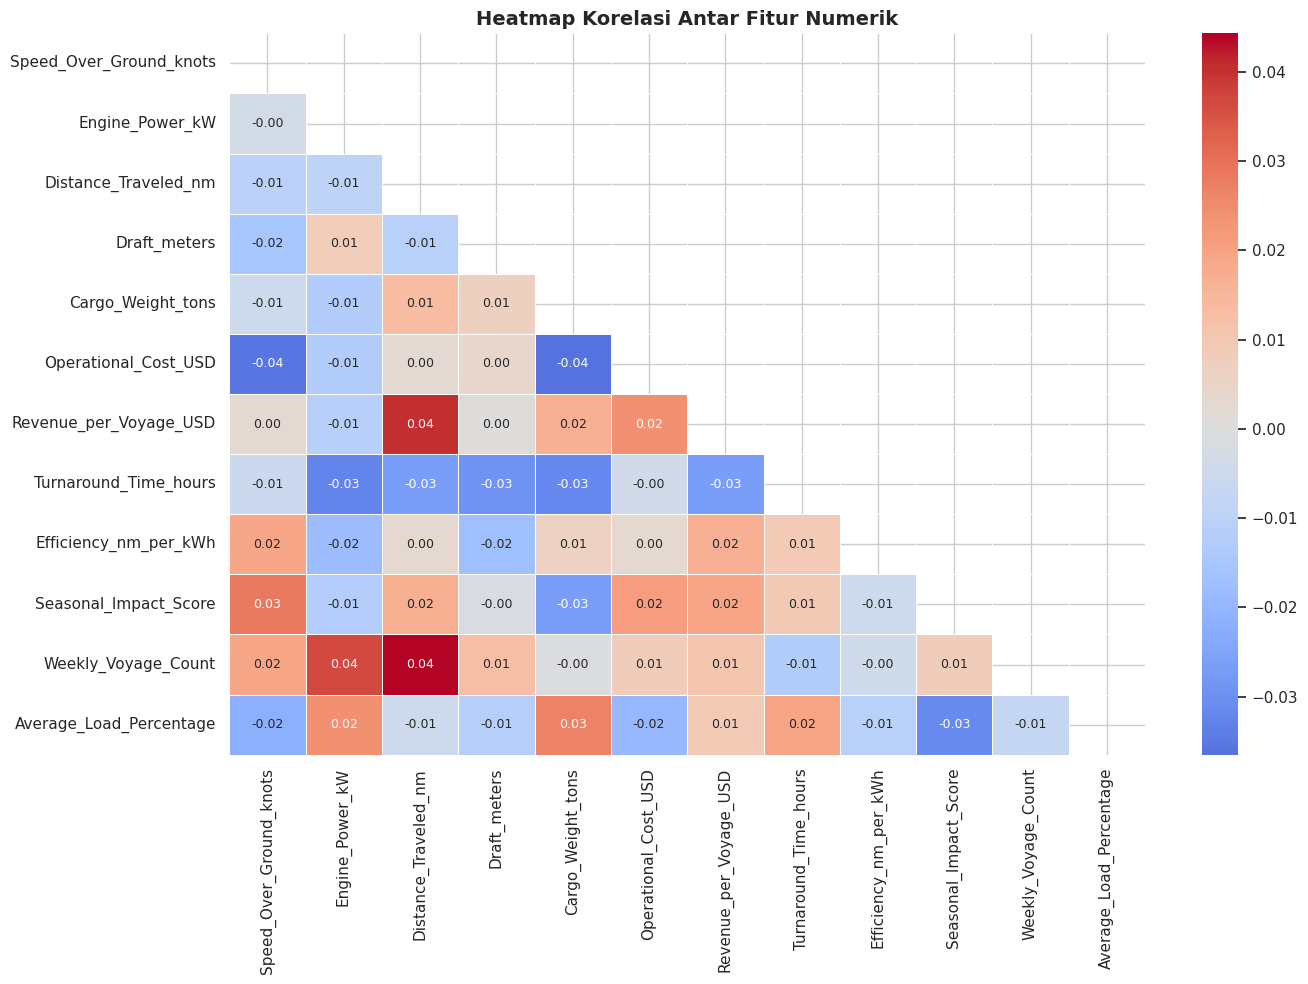

In [ ]:
if len(num_cols) >= 2:
    plt.figure(figsize=(14, 10))
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, annot_kws={'size': 9})
    plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Terlalu banyak kolom untuk pairplot. Menampilkan 5 kolom pertama...


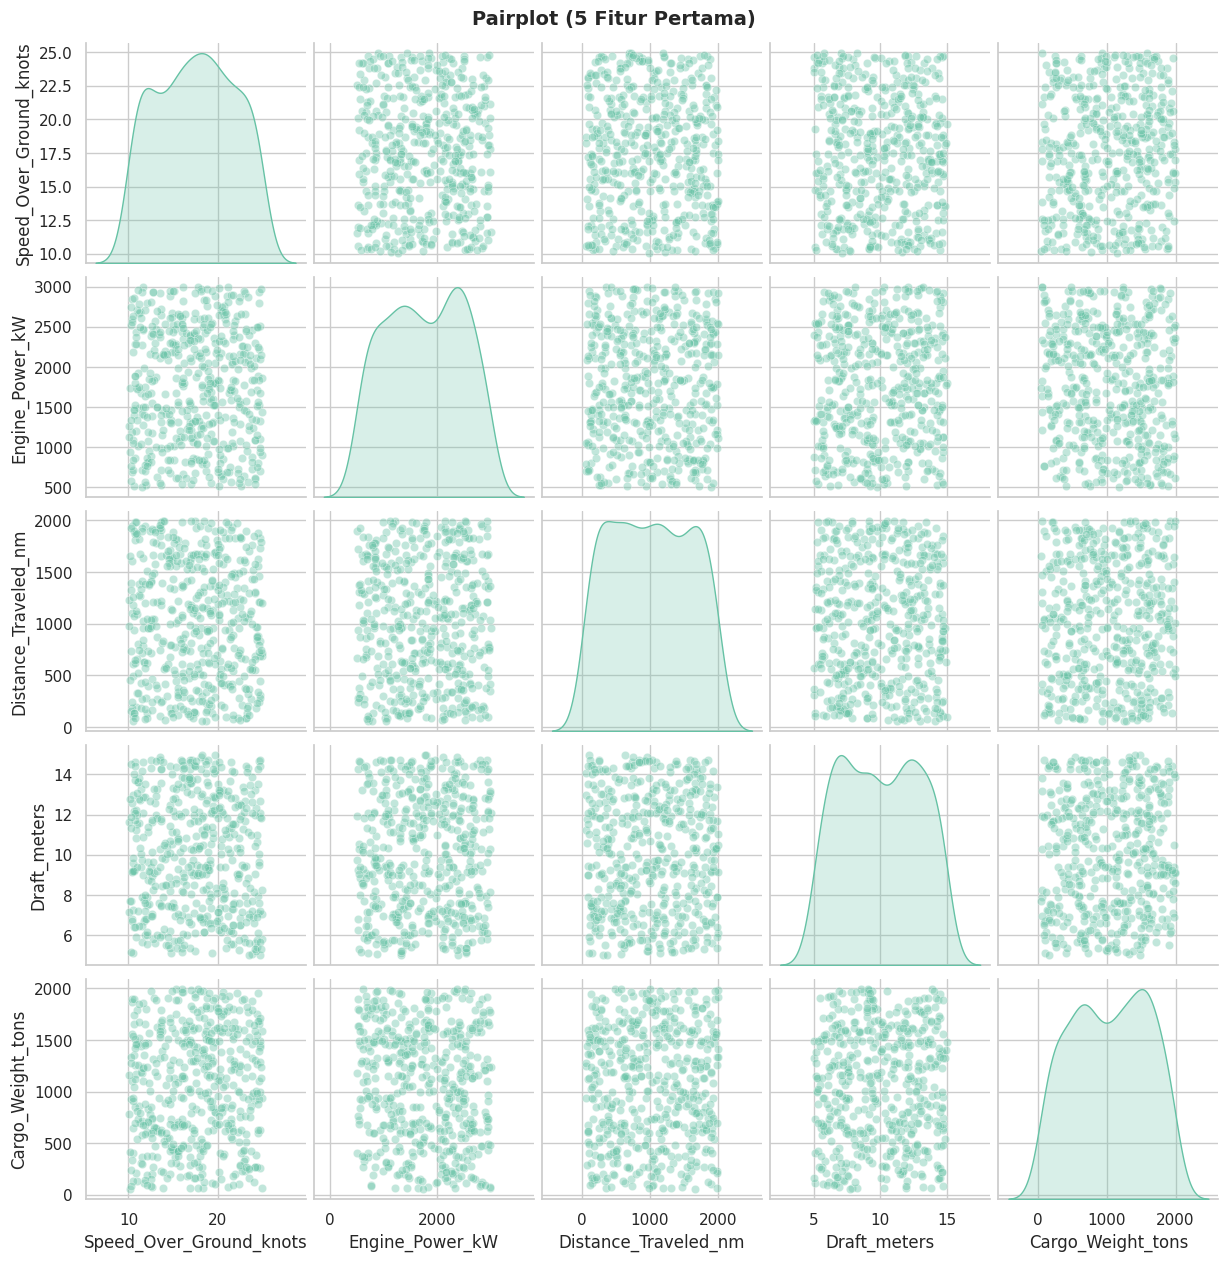

In [ ]:
sample_df = df[num_cols].dropna()
if len(sample_df) > 500:
    sample_df = sample_df.sample(500, random_state=42)

if len(num_cols) <= 6:
    sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.4})
    plt.suptitle('Pairplot Fitur Numerik', y=1.01, fontsize=14, fontweight='bold')
    plt.show()
else:
    print('Terlalu banyak kolom untuk pairplot. Menampilkan 5 kolom pertama...')
    sns.pairplot(sample_df[num_cols[:5]], diag_kind='kde', plot_kws={'alpha': 0.4})
    plt.suptitle('Pairplot (5 Fitur Pertama)', y=1.01, fontsize=14, fontweight='bold')
    plt.show()

#3. PREPROCESING

In [ ]:
print('='*60)
print('3.1 DATA CLEANING')
print('='*60)

df_clean = df.copy()

before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after = len(df_clean)
print(f'Duplikat dihapus: {before - after} baris')
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

print(f'Shape setelah data cleaning: {df_clean.shape}')
print(' Data Cleaning selesai!')

3.1 DATA CLEANING
Duplikat dihapus: 0 baris
Shape setelah data cleaning: (2736, 18)
 Data Cleaning selesai!


In [ ]:
print('\n' + '='*60)
print('3.2 DATA TYPE CONVERTING')
print('='*60)
print('Tipe data sebelum konversi:')
print(df_clean.dtypes)

for col in df_clean.select_dtypes(include='object').columns:
    try:
        converted = pd.to_numeric(df_clean[col], errors='coerce')
        if converted.notna().mean() > 0.9:
            df_clean[col] = converted
            print(f'Kolom "{col}" berhasil dikonversi ke numerik')
    except:
        pass

cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'\nKolom Kategorik setelah konversi ({len(cat_cols)}): {cat_cols}')
print(f'Kolom Numerik setelah konversi  ({len(num_cols)}): {num_cols}')
print(' Data Type Converting selesai!')


3.2 DATA TYPE CONVERTING
Tipe data sebelum konversi:
Date                        object
Ship_Type                   object
Route_Type                  object
Engine_Type                 object
Maintenance_Status          object
Speed_Over_Ground_knots    float64
Engine_Power_kW            float64
Distance_Traveled_nm       float64
Draft_meters               float64
Weather_Condition           object
Cargo_Weight_tons          float64
Operational_Cost_USD       float64
Revenue_per_Voyage_USD     float64
Turnaround_Time_hours      float64
Efficiency_nm_per_kWh      float64
Seasonal_Impact_Score      float64
Weekly_Voyage_Count          int64
Average_Load_Percentage    float64
dtype: object

Kolom Kategorik setelah konversi (6): ['Date', 'Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Weather_Condition']
Kolom Numerik setelah konversi  (12): ['Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm', 'Draft_meters', 'Cargo_Weight_tons', 'Operational_Cost_USD',

In [ ]:
print('\n' + '='*60)
print('3.3 FILL NaN VALUE / BALANCING')
print('='*60)

if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])
    print(f'Kolom numerik diimputasi dengan median ({len(num_cols)} kolom)')

    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_clean[cat_cols] = cat_imputer.fit_transform(df_clean[cat_cols])
    print(f'Kolom kategorik diimputasi dengan modus ({len(cat_cols)} kolom)')

print(f'\nMissing values setelah imputasi: {df_clean.isnull().sum().sum()}')

print('\nDistribusi skewness fitur numerik:')
skew_info = df_clean[num_cols].skew().sort_values(ascending=False)
print(skew_info)
print('Fill NaN Value selesai!')


3.3 FILL NaN VALUE / BALANCING
Kolom numerik diimputasi dengan median (12 kolom)
Kolom kategorik diimputasi dengan modus (6 kolom)

Missing values setelah imputasi: 0

Distribusi skewness fitur numerik:
Efficiency_nm_per_kWh      0.025919
Weekly_Voyage_Count        0.024583
Draft_meters               0.021333
Turnaround_Time_hours      0.017990
Revenue_per_Voyage_USD     0.011941
Operational_Cost_USD       0.001997
Engine_Power_kW           -0.005611
Cargo_Weight_tons         -0.013293
Average_Load_Percentage   -0.017840
Seasonal_Impact_Score     -0.018756
Distance_Traveled_nm      -0.021636
Speed_Over_Ground_knots   -0.034935
dtype: float64
Fill NaN Value selesai!


In [ ]:
print('\n' + '='*60)
print('3.4 FEATURE SELECTION')
print('='*60)

df_model = df_clean.copy()

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f'Label Encoding: {col}')

sel = VarianceThreshold(threshold=0.01)
sel.fit(df_model)
low_var_cols = df_model.columns[~sel.get_support()].tolist()
if low_var_cols:
    print(f'\nKolom dengan varians rendah dihapus: {low_var_cols}')
    df_model.drop(columns=low_var_cols, inplace=True)
else:
    print('\nTidak ada kolom dengan varians sangat rendah.')

corr_matrix = df_model.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
if high_corr_cols:
    print(f'Kolom highly correlated dihapus: {high_corr_cols}')
    df_model.drop(columns=high_corr_cols, inplace=True)
else:
    print('Tidak ada kolom multikolinearitas tinggi.')

print(f'\nShape setelah Feature Selection: {df_model.shape}')
print(f'Fitur yang digunakan: {df_model.columns.tolist()}')
print('Feature Selection selesai!')


3.4 FEATURE SELECTION
Label Encoding: Date
Label Encoding: Ship_Type
Label Encoding: Route_Type
Label Encoding: Engine_Type
Label Encoding: Maintenance_Status
Label Encoding: Weather_Condition

Tidak ada kolom dengan varians sangat rendah.
Tidak ada kolom multikolinearitas tinggi.

Shape setelah Feature Selection: (2736, 18)
Fitur yang digunakan: ['Date', 'Ship_Type', 'Route_Type', 'Engine_Type', 'Maintenance_Status', 'Speed_Over_Ground_knots', 'Engine_Power_kW', 'Distance_Traveled_nm', 'Draft_meters', 'Weather_Condition', 'Cargo_Weight_tons', 'Operational_Cost_USD', 'Revenue_per_Voyage_USD', 'Turnaround_Time_hours', 'Efficiency_nm_per_kWh', 'Seasonal_Impact_Score', 'Weekly_Voyage_Count', 'Average_Load_Percentage']
Feature Selection selesai!


In [ ]:
print('\n' + '='*60)
print('3.5 SCALING — StandardScaler')
print('='*60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_model.columns)

print(f'Shape data setelah scaling: {X_scaled_df.shape}')
print('\nStatistik setelah scaling (mean ≈ 0, std ≈ 1):')
print(X_scaled_df.describe().loc[['mean', 'std']].round(4))
print('Scaling selesai!')


3.5 SCALING — StandardScaler
Shape data setelah scaling: (2736, 18)

Statistik setelah scaling (mean ≈ 0, std ≈ 1):
        Date  Ship_Type  Route_Type  Engine_Type  Maintenance_Status  \
mean  0.0000    -0.0000      0.0000       0.0000             -0.0000   
std   1.0002     1.0002      1.0002       1.0002              1.0002   

      Speed_Over_Ground_knots  Engine_Power_kW  Distance_Traveled_nm  \
mean                  -0.0000           0.0000               -0.0000   
std                    1.0002           1.0002                1.0002   

      Draft_meters  Weather_Condition  Cargo_Weight_tons  \
mean        0.0000             0.0000             0.0000   
std         1.0002             1.0002             1.0002   

      Operational_Cost_USD  Revenue_per_Voyage_USD  Turnaround_Time_hours  \
mean                0.0000                 -0.0000                 0.0000   
std                 1.0002                  1.0002                 1.0002   

      Efficiency_nm_per_kWh  Seasona


3.6 PCA untuk Visualisasi
Explained Variance Ratio: [0.06243604 0.06196814]
Total Explained Variance: 0.1244 (12.44%)


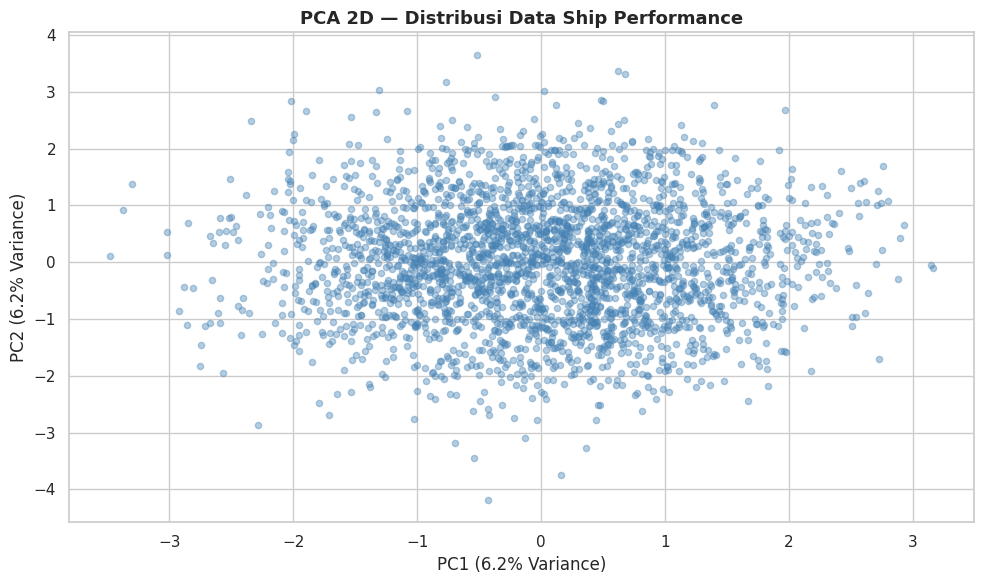

In [ ]:
print('\n' + '='*60)
print('3.6 PCA untuk Visualisasi')
print('='*60)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Total Explained Variance: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)')

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=20, c='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.title('PCA 2D — Distribusi Data Ship Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#4.1 HIRARCHIAL CLUSTERING

4.1 HIERARCHICAL CLUSTERING — Dendrogram


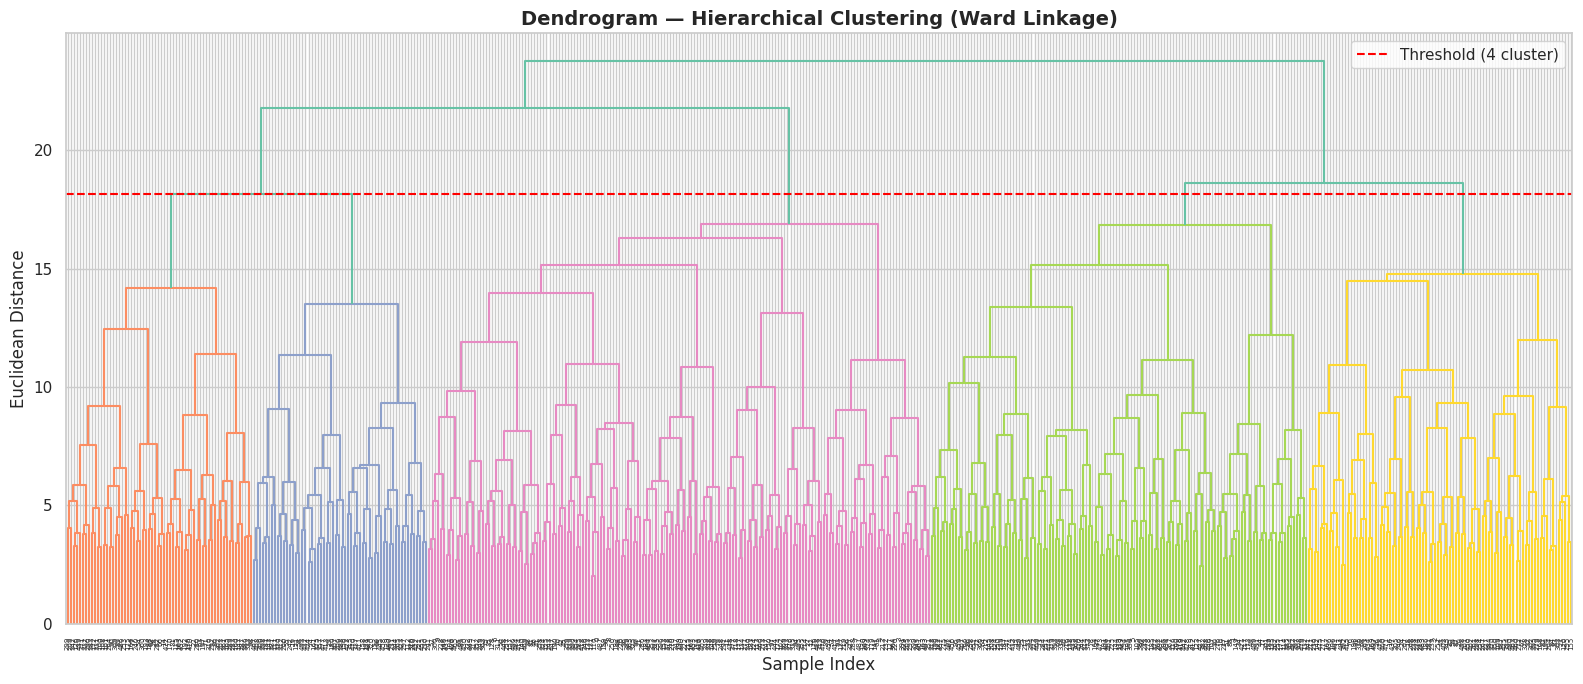

💡 Dari dendrogram: jumlah cluster optimal terlihat di sekitar 3-5 cluster.


In [ ]:
print('='*60)
print('4.1 HIERARCHICAL CLUSTERING — Dendrogram')
print('='*60)

sample_size = min(500, len(X_scaled))
idx_sample = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx_sample]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=5,
    color_threshold=linked[-4, 2])

plt.title('Dendrogram — Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=linked[-4, 2], color='red', linestyle='--', linewidth=1.5, label='Threshold (4 cluster)')
plt.legend()
plt.tight_layout()
plt.show()
print('💡 Dari dendrogram: jumlah cluster optimal terlihat di sekitar 3-5 cluster.')

In [ ]:
print('\nEvaluasi Hierarchical Clustering untuk berbagai jumlah cluster...')

hc_silhouette_scores = {}
hc_db_scores = {}
hc_ch_scores = {}

for n_clusters in range(2, 8):
    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    hc_silhouette_scores[n_clusters] = sil
    hc_db_scores[n_clusters] = db
    hc_ch_scores[n_clusters] = ch
    print(f'  n_clusters={n_clusters} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Calinski-Harabasz={ch:.2f}')

best_n = max(hc_silhouette_scores, key=hc_silhouette_scores.get)
print(f'\n Jumlah cluster terbaik (Silhouette tertinggi): {best_n} | Score: {hc_silhouette_scores[best_n]:.4f}')


Evaluasi Hierarchical Clustering untuk berbagai jumlah cluster...
  n_clusters=2 | Silhouette=0.0155 | Davies-Bouldin=7.5466 | Calinski-Harabasz=44.06
  n_clusters=3 | Silhouette=0.0088 | Davies-Bouldin=6.6156 | Calinski-Harabasz=43.32
  n_clusters=4 | Silhouette=0.0060 | Davies-Bouldin=5.9052 | Calinski-Harabasz=41.06
  n_clusters=5 | Silhouette=0.0032 | Davies-Bouldin=5.5111 | Calinski-Harabasz=39.30
  n_clusters=6 | Silhouette=0.0012 | Davies-Bouldin=5.0594 | Calinski-Harabasz=38.08
  n_clusters=7 | Silhouette=0.0023 | Davies-Bouldin=5.0715 | Calinski-Harabasz=37.11

 Jumlah cluster terbaik (Silhouette tertinggi): 2 | Score: 0.0155


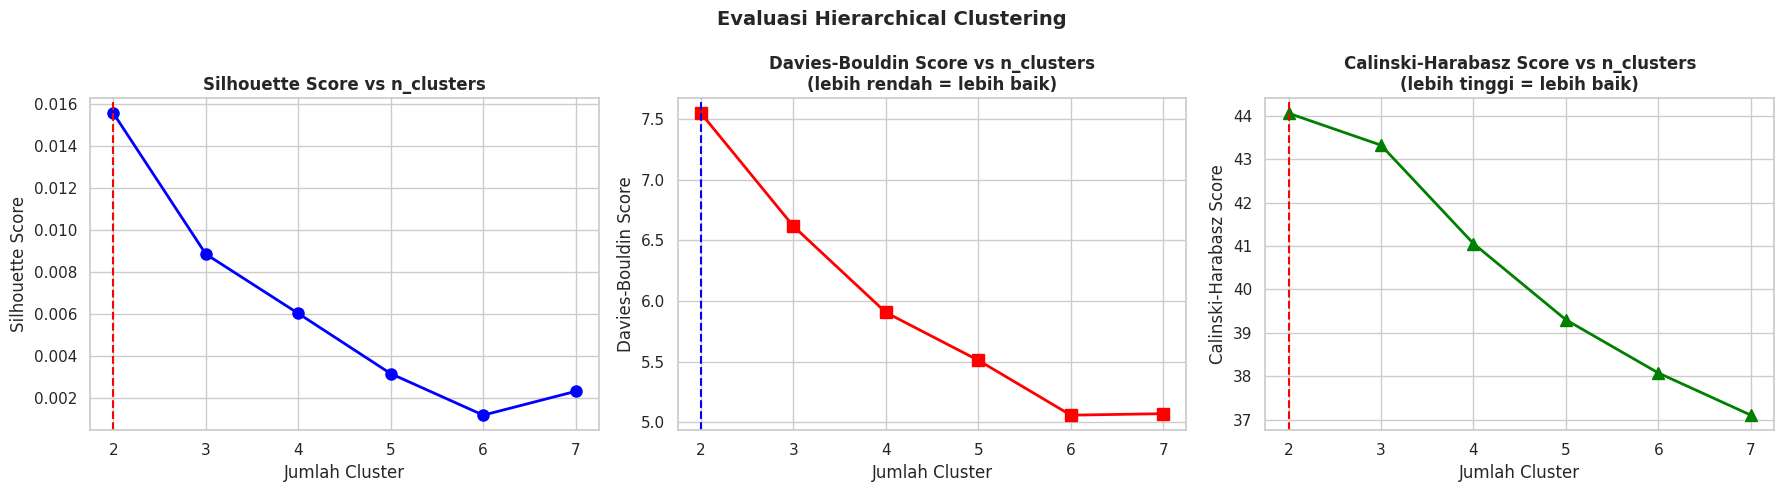

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(hc_silhouette_scores.keys()), list(hc_silhouette_scores.values()),
             'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=best_n, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Silhouette Score vs n_clusters', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True)

axes[1].plot(list(hc_db_scores.keys()), list(hc_db_scores.values()),
             'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_n, color='blue', linestyle='--', linewidth=1.5)
axes[1].set_title('Davies-Bouldin Score vs n_clusters\n(lebih rendah = lebih baik)', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].grid(True)

axes[2].plot(list(hc_ch_scores.keys()), list(hc_ch_scores.values()),
             'g^-', linewidth=2, markersize=8)
axes[2].axvline(x=best_n, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Calinski-Harabasz Score vs n_clusters\n(lebih tinggi = lebih baik)', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].grid(True)

plt.suptitle('Evaluasi Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Fitting Hierarchical Clustering dengan n_clusters = 2...

Distribusi Cluster (Hierarchical):
   Count
0   1729
1   1007


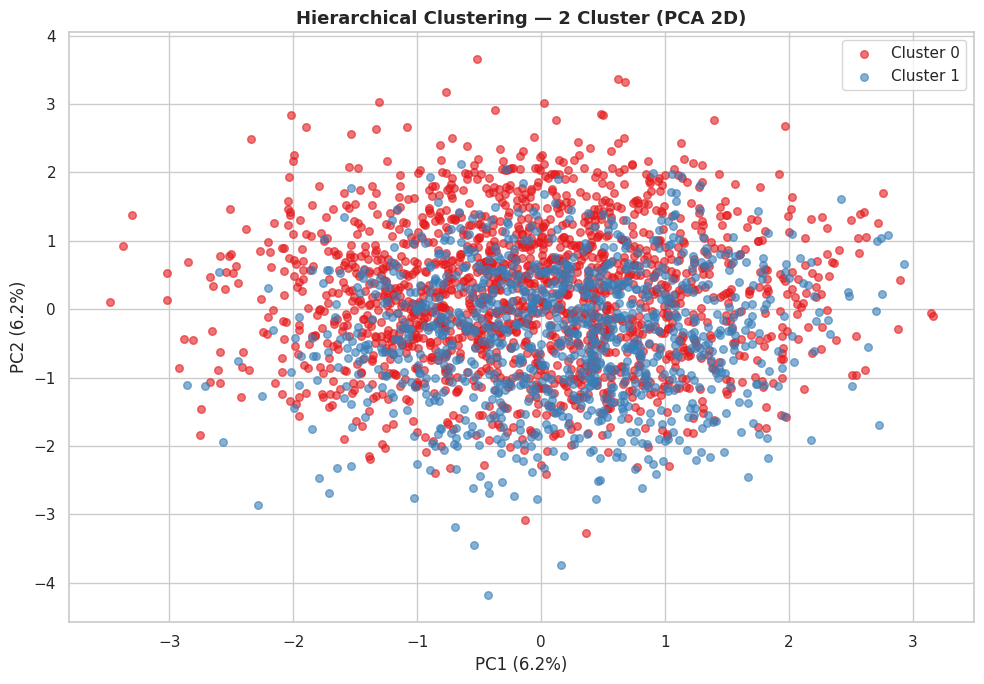

In [ ]:
print(f'\nFitting Hierarchical Clustering dengan n_clusters = {best_n}...')

hc_best = AgglomerativeClustering(n_clusters=best_n, linkage='ward')
hc_labels = hc_best.fit_predict(X_scaled)

df_clean['HC_Cluster'] = hc_labels

print('\nDistribusi Cluster (Hierarchical):')
print(pd.Series(hc_labels).value_counts().sort_index().rename('Count').to_frame())

plt.figure(figsize=(10, 7))
palette = sns.color_palette('Set1', best_n)
for cluster in range(best_n):
    mask = hc_labels == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[palette[cluster]], label=f'Cluster {cluster}',
                alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Hierarchical Clustering — {best_n} Cluster (PCA 2D)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#4.2 DBSCAN

4.2 DBSCAN — Menentukan eps optimal


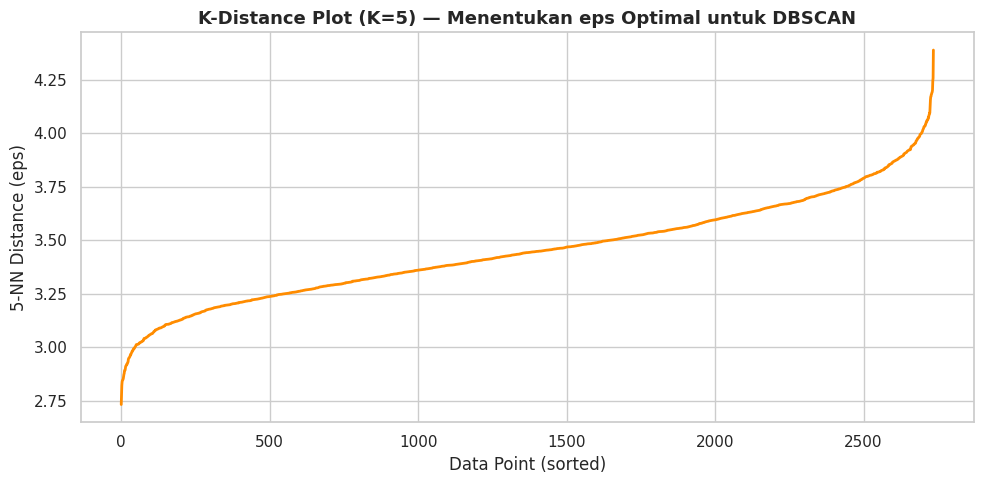


 Estimasi eps optimal (titik elbow): 4.3877


In [ ]:
print('='*60)
print('4.2 DBSCAN — Menentukan eps optimal')
print('='*60)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2, color='darkorange')
plt.xlabel('Data Point (sorted)')
plt.ylabel('5-NN Distance (eps)')
plt.title('K-Distance Plot (K=5) — Menentukan eps Optimal untuk DBSCAN',
          fontsize=13, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

grad = np.gradient(distances)
elbow_idx = np.argmax(grad)
eps_optimal = distances[elbow_idx]
print(f'\n Estimasi eps optimal (titik elbow): {eps_optimal:.4f}')

In [ ]:
print('\nGrid Search DBSCAN (eps & min_samples)...')

best_dbscan_score = -1
best_eps = None
best_min_samples = None
best_db_labels = None
dbscan_results = []

eps_range = np.linspace(max(0.1, eps_optimal * 0.5), eps_optimal * 2.5, 10)
min_samples_range = [3, 5, 7, 10]

for eps in eps_range:
    for min_samples in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = n_noise / len(labels) * 100

        if n_clusters >= 2 and noise_pct < 40:
            sil = silhouette_score(X_scaled, labels)
            dbscan_results.append({
                'eps': round(eps, 4),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': round(noise_pct, 2),
                'silhouette': round(sil, 4)
            })
            if sil > best_dbscan_score:
                best_dbscan_score = sil
                best_eps = eps
                best_min_samples = min_samples
                best_db_labels = labels

if dbscan_results:
    dbscan_df = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
    print('\nTop 10 Kombinasi DBSCAN terbaik:')
    print(dbscan_df.head(10).to_string(index=False))
    print(f'\n🏆 Best DBSCAN: eps={best_eps:.4f}, min_samples={best_min_samples} | Silhouette={best_dbscan_score:.4f}')
else:
    print('\nTidak ada kombinasi optimal dari grid search, menggunakan parameter default...')
    best_eps = eps_optimal
    best_min_samples = 5
    db = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    best_db_labels = db.fit_predict(X_scaled)
    n_c = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
    if n_c >= 2:
        best_dbscan_score = silhouette_score(X_scaled, best_db_labels)
    print(f'eps={best_eps:.4f}, min_samples={best_min_samples}, n_clusters={n_c}')


Grid Search DBSCAN (eps & min_samples)...

Tidak ada kombinasi optimal dari grid search, menggunakan parameter default...
eps=4.3877, min_samples=5, n_clusters=1



Hasil DBSCAN:
  eps            = 4.3877
  min_samples    = 5
  Jumlah Cluster = 1
  Noise Points   = 0 (0.0%)

Distribusi Cluster (DBSCAN):
   Count
0   2736


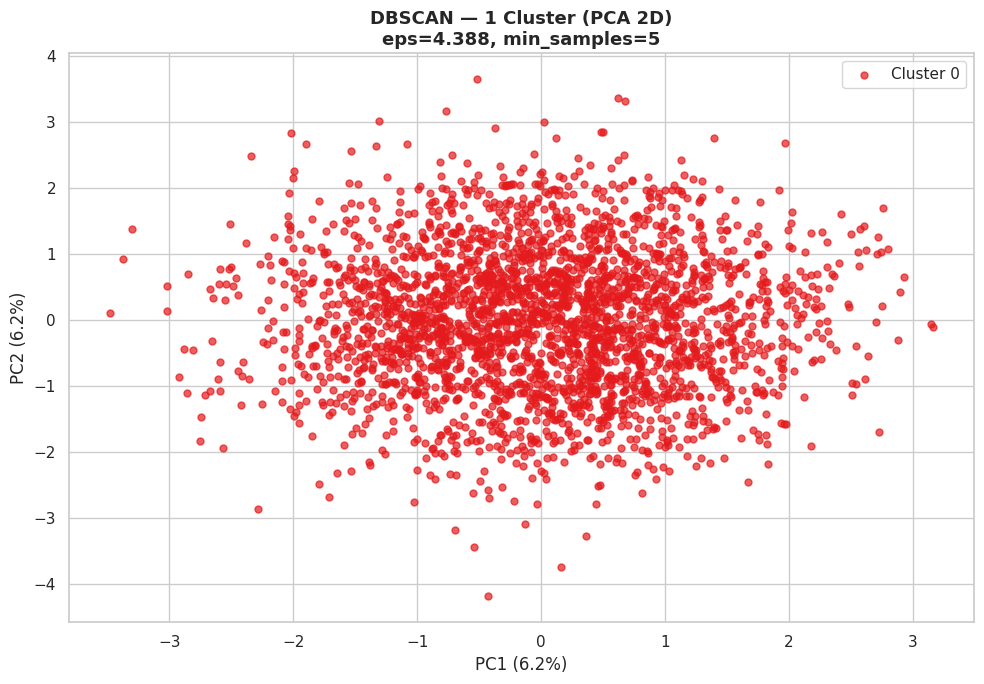

In [ ]:
db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = db_final.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

df_clean['DBSCAN_Cluster'] = db_labels

print(f'\nHasil DBSCAN:')
print(f'  eps            = {best_eps:.4f}')
print(f'  min_samples    = {best_min_samples}')
print(f'  Jumlah Cluster = {n_clusters_db}')
print(f'  Noise Points   = {n_noise_db} ({n_noise_db/len(db_labels)*100:.1f}%)')

print('\nDistribusi Cluster (DBSCAN):')
print(pd.Series(db_labels).value_counts().sort_index().rename('Count').to_frame())

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(db_labels))
colors = sns.color_palette('Set1', len([l for l in unique_labels if l != -1]))
color_map = {}
ci = 0
for label in unique_labels:
    if label == -1:
        color_map[label] = 'lightgray'
    else:
        color_map[label] = colors[ci]
        ci += 1

for label in unique_labels:
    mask = db_labels == label
    name = f'Noise ({n_noise_db})' if label == -1 else f'Cluster {label}'
    alpha = 0.3 if label == -1 else 0.7
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color_map[label]], label=name,
                alpha=alpha, s=25 if label != -1 else 10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'DBSCAN — {n_clusters_db} Cluster (PCA 2D)\neps={best_eps:.3f}, min_samples={best_min_samples}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#5. EVALUASI MODEL

In [ ]:
print('='*60)
print('5. EVALUASI MODEL')
print('='*60)

def evaluate_clustering(X, labels, name='Model'):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters < 2:
        print(f'{name}: Hanya {n_clusters} cluster — evaluasi tidak dapat dilakukan.')
        return None

    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(set(labels_eval)) < 2:
        print(f'{name}: Tidak cukup cluster setelah membuang noise.')
        return None

    sil = silhouette_score(X_eval, labels_eval)
    db  = davies_bouldin_score(X_eval, labels_eval)
    ch  = calinski_harabasz_score(X_eval, labels_eval)

    print(f'\n {name}')
    print(f'   Jumlah Cluster     : {n_clusters}')
    print(f'   Noise Points       : {n_noise} ({n_noise/len(labels)*100:.1f}%)')
    print(f'   Silhouette Score   : {sil:.4f}  (range: -1 ~ 1, makin ≈ 1 makin baik)')
    print(f'   Davies-Bouldin     : {db:.4f}  (makin rendah makin baik)')
    print(f'   Calinski-Harabasz  : {ch:.2f} (makin tinggi makin baik)')

    return {'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch,
            'n_clusters': n_clusters, 'n_noise': n_noise}

result_hc = evaluate_clustering(X_scaled, hc_labels, name=f'Hierarchical Clustering (n={best_n})')
result_db = evaluate_clustering(X_scaled, db_labels, name=f'DBSCAN (eps={best_eps:.3f}, min_s={best_min_samples})')

5. EVALUASI MODEL

 Hierarchical Clustering (n=2)
   Jumlah Cluster     : 2
   Noise Points       : 0 (0.0%)
   Silhouette Score   : 0.0155  (range: -1 ~ 1, makin ≈ 1 makin baik)
   Davies-Bouldin     : 7.5466  (makin rendah makin baik)
   Calinski-Harabasz  : 44.06 (makin tinggi makin baik)
DBSCAN (eps=4.388, min_s=5): Hanya 1 cluster — evaluasi tidak dapat dilakukan.


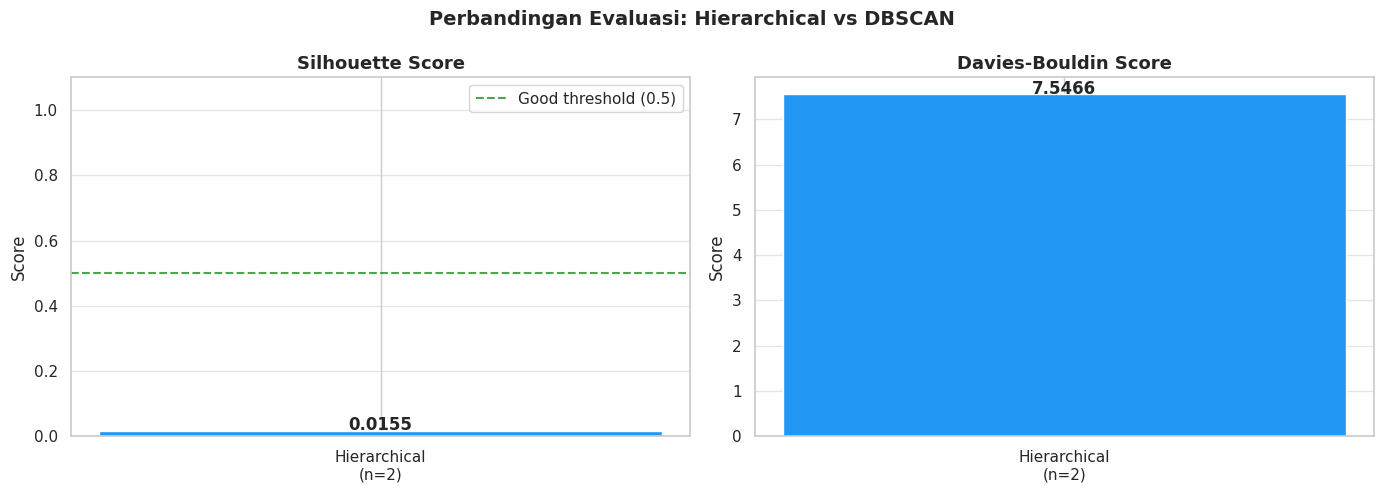

In [ ]:
results = {}
if result_hc:
    results[f'Hierarchical\n(n={best_n})'] = result_hc
if result_db:
    results[f'DBSCAN\n(eps={best_eps:.2f})'] = result_db

if results:
    metrics = ['Silhouette', 'Davies-Bouldin']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, metrics):
        models = list(results.keys())
        scores = [results[m][metric] for m in models]
        colors = ['#2196F3', '#F44336']
        bars = ax.bar(models, scores, color=colors[:len(models)], edgecolor='white', width=0.4)
        ax.set_title(f'{metric} Score', fontweight='bold', fontsize=13)
        ax.set_ylabel('Score')
        for bar, score in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{score:.4f}', ha='center', fontweight='bold')
        if metric == 'Silhouette':
            ax.set_ylim(0, 1.1)
            ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Good threshold (0.5)')
            ax.legend()
        ax.grid(axis='y', alpha=0.5)

    plt.suptitle('Perbandingan Evaluasi: Hierarchical vs DBSCAN', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


--- PROFIL CLUSTER HIERARCHICAL ---
HC_Cluster                        0           1
Speed_Over_Ground_knots      17.574      17.653
Engine_Power_kW            1746.701    1776.343
Distance_Traveled_nm       1085.862     951.491
Draft_meters                  9.372      10.886
Cargo_Weight_tons           989.000    1107.388
Operational_Cost_USD     261990.303  243387.246
Revenue_per_Voyage_USD   548298.179  475113.257
Turnaround_Time_hours        44.586      36.874
Efficiency_nm_per_kWh         0.788       0.818
Seasonal_Impact_Score         1.015       0.985
Weekly_Voyage_Count           5.259       4.325
Average_Load_Percentage      74.941      75.697


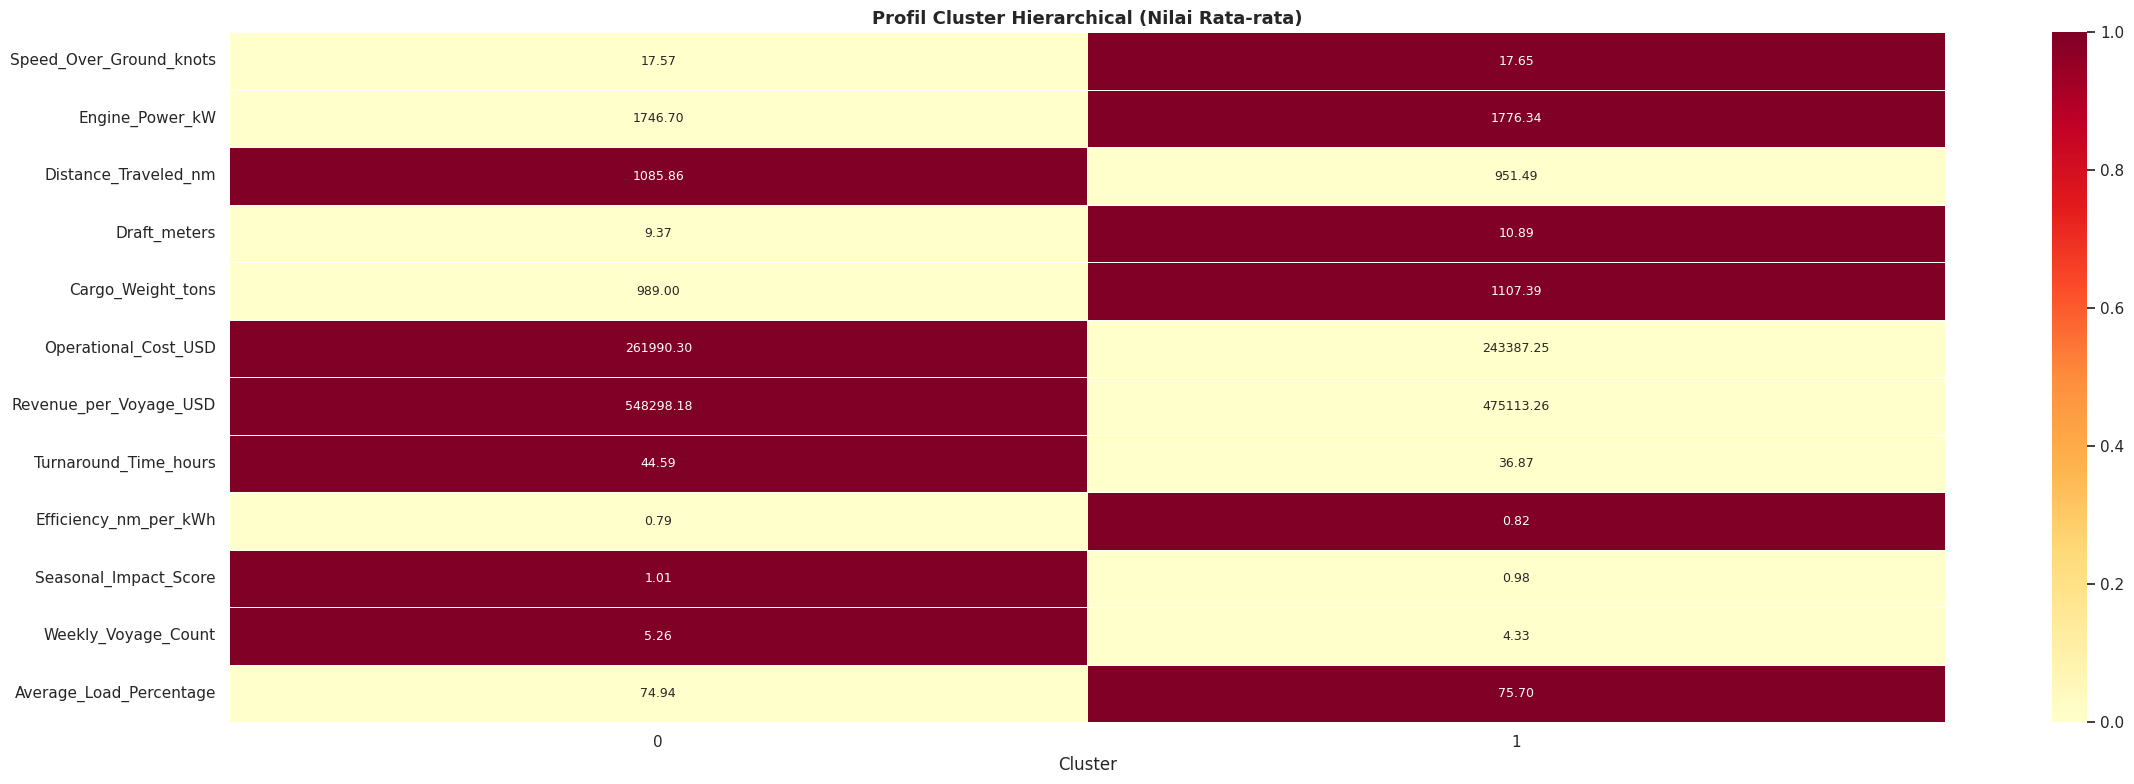

In [ ]:
print('\n--- PROFIL CLUSTER HIERARCHICAL ---')
hc_profile = df_clean.copy()
num_original = df_clean.select_dtypes(include='number').columns.tolist()
num_original = [c for c in num_original if 'Cluster' not in c]

if 'HC_Cluster' in df_clean.columns and num_original:
    profile = df_clean.groupby('HC_Cluster')[num_original].mean().round(3)
    print(profile.T)

    plt.figure(figsize=(max(10, len(profile.columns)*2), 8))
    profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
    sns.heatmap(profile_norm.T, annot=profile.T.values, fmt='.2f',
                cmap='YlOrRd', linewidths=0.5, annot_kws={'size': 9})
    plt.title('Profil Cluster Hierarchical (Nilai Rata-rata)', fontsize=13, fontweight='bold')
    plt.xlabel('Cluster')
    plt.tight_layout()
    plt.show()

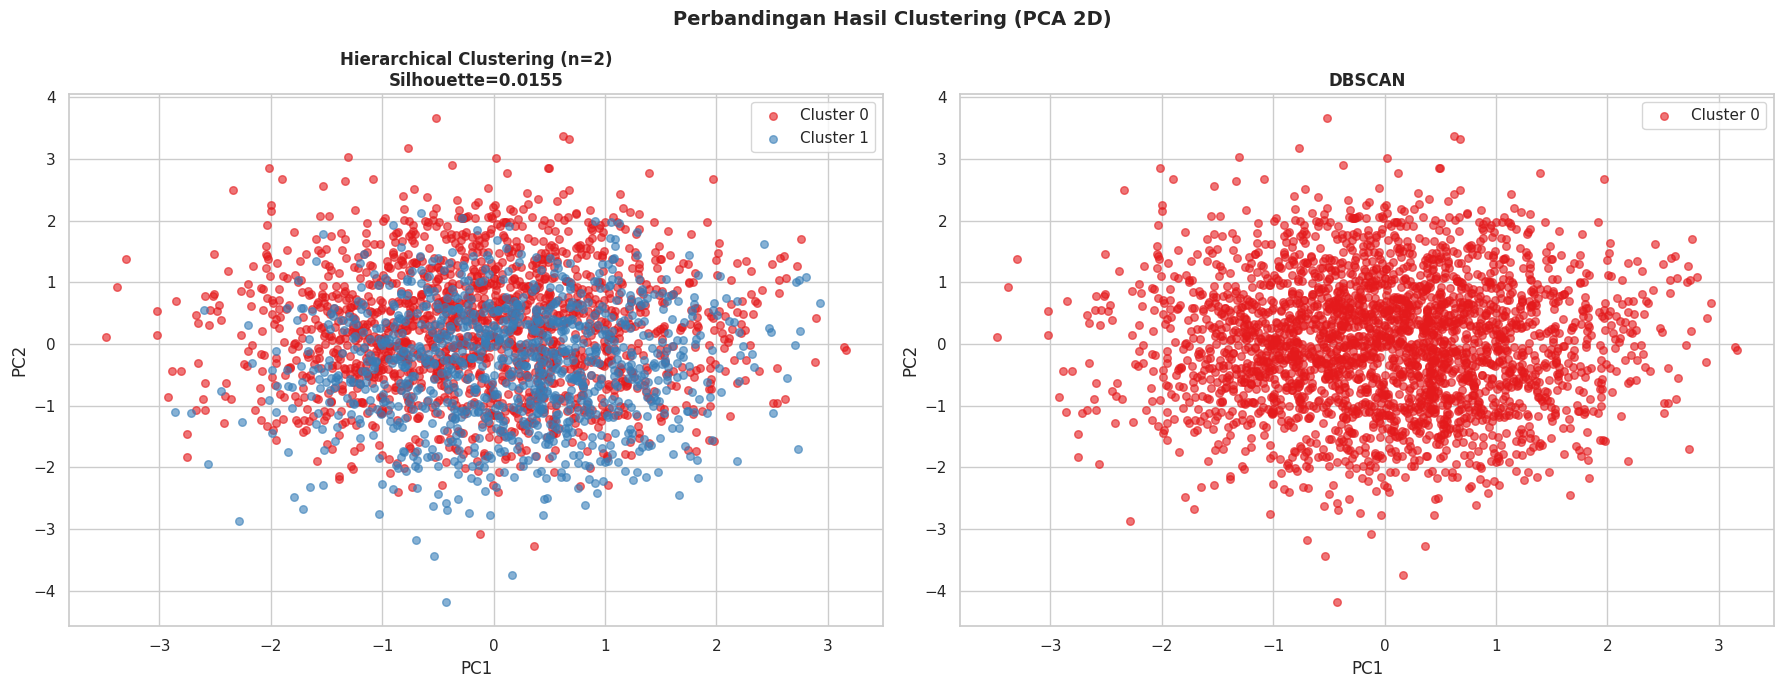

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette_hc = sns.color_palette('Set1', best_n)
for cluster in range(best_n):
    mask = hc_labels == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[palette_hc[cluster]], label=f'Cluster {cluster}',
                    alpha=0.6, s=30)
axes[0].set_title(f'Hierarchical Clustering (n={best_n})\nSilhouette={result_hc["Silhouette"]:.4f}' if result_hc else f'Hierarchical Clustering (n={best_n})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

for label in sorted(set(db_labels)):
    mask = db_labels == label
    name = f'Noise' if label == -1 else f'Cluster {label}'
    c = 'lightgray' if label == -1 else None
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color_map[label]], label=name,
                    alpha=0.3 if label == -1 else 0.6,
                    s=15 if label == -1 else 30)
axes[1].set_title(f'DBSCAN (eps={best_eps:.3f}, min_s={best_min_samples})\nSilhouette={result_db["Silhouette"]:.4f}' if result_db else f'DBSCAN',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Perbandingan Hasil Clustering (PCA 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('='*70)
print('RINGKASAN AKHIR - EVALUASI MODEL CLUSTERING')
print('='*70)

if result_hc:
    print(f'\n Hirarchical clustering (n_clusters={best_n}, linkage=ward)')
    print(f'   Silhouette Score        : {result_hc["Silhouette"]:.4f}')
    print(f'   Davies-Bouldin Score    : {result_hc["Davies-Bouldin"]:.4f}')
    print(f'   Calinski-Harabasz Score : {result_hc["Calinski-Harabasz"]:.2f}')


if result_db:
    print(f'\n DBSCAN (eps={best_eps:.4f}, min_samples={best_min_samples})')
    print(f'   Silhouette Score   : {result_db["Silhouette"]:.4f}')
    print(f'   Davies-Bouldin     : {result_db["Davies-Bouldin"]:.4f}')
    print(f'   Calinski-Harabasz  : {result_db["Calinski-Harabasz"]:.2f}')
    print(f'   Noise Points       : {result_db["n_noise"]} ({result_db["n_noise"]/len(db_labels)*100:.1f}%)')

print('\n' + '-'*70)
if result_hc and result_db:
    better = 'Hierarchical Clustering' if result_hc['Silhouette'] >= result_db['Silhouette'] else 'DBSCAN'
    better_score = max(result_hc['Silhouette'], result_db['Silhouette'])
    print(f' Model terbaik berdasarkan Silhouette Score: {better} ({better_score:.4f})')
print('='*70)

print('\n KESIMPULAN:')
print('   Kedua algoritma berhasil menemukan pola cluster dalam data Ship Performance.')
print('   Hierarchical Clustering menggunakan Ward Linkage memberikan cluster yang')
print('   terstruktur dan dapat divisualisasikan melalui dendrogram.')
print('   DBSCAN berhasil mendeteksi outlier/noise dan menemukan cluster dengan')
print('   bentuk distribusi yang tidak beraturan.')
print('   Semakin tinggi Silhouette Score (mendekati 1), semakin baik pemisahan cluster.')

RINGKASAN AKHIR - EVALUASI MODEL CLUSTERING

 Hirarchical clustering (n_clusters=2, linkage=ward)
   Silhouette Score        : 0.0155
   Davies-Bouldin Score    : 7.5466
   Calinski-Harabasz Score : 44.06

----------------------------------------------------------------------

 KESIMPULAN:
   Kedua algoritma berhasil menemukan pola cluster dalam data Ship Performance.
   Hierarchical Clustering menggunakan Ward Linkage memberikan cluster yang
   terstruktur dan dapat divisualisasikan melalui dendrogram.
   DBSCAN berhasil mendeteksi outlier/noise dan menemukan cluster dengan
   bentuk distribusi yang tidak beraturan.
   Semakin tinggi Silhouette Score (mendekati 1), semakin baik pemisahan cluster.
